In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

print("TensorFlow version:", tf.__version__)
print("All libraries loaded successfully!")

TensorFlow version: 2.21.0
All libraries loaded successfully!


In [7]:

dataset_path = r"D:\HematoVision\archive\dataset2-master\dataset2-master\images\TRAIN"

# Let's check that the folders are there
for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)
    if os.path.isdir(folder_path):
        count = len(os.listdir(folder_path))
        print(f"Folder: {folder}  →  {count} images")

Folder: EOSINOPHIL  →  2497 images
Folder: LYMPHOCYTE  →  2483 images
Folder: MONOCYTE  →  2478 images
Folder: NEUTROPHIL  →  2499 images


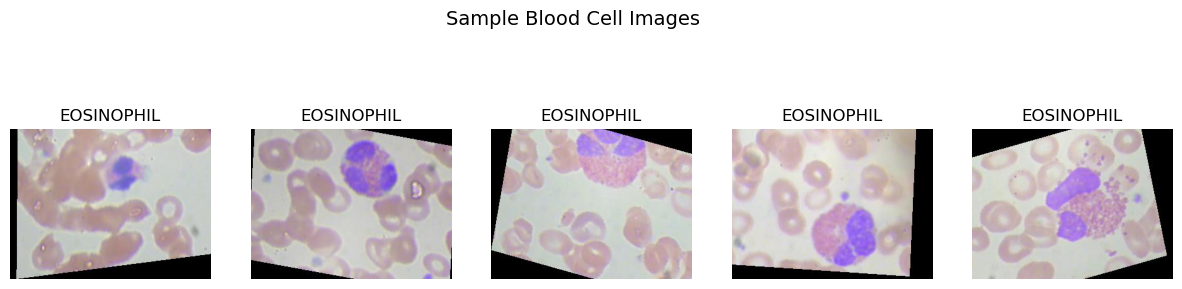

In [8]:
# Pick one category to preview
sample_folder = os.path.join(dataset_path, os.listdir(dataset_path)[0])

# Pick 5 random images from it
sample_images = random.sample(os.listdir(sample_folder), 5)

plt.figure(figsize=(15, 4))
for i, img_name in enumerate(sample_images):
    img_path = os.path.join(sample_folder, img_name)
    img = plt.imread(img_path)
    plt.subplot(1, 5, i+1)
    plt.imshow(img)
    plt.title(os.listdir(dataset_path)[0])
    plt.axis('off')

plt.suptitle("Sample Blood Cell Images", fontsize=14)
plt.show()

In [11]:
# Path to TRAIN and TEST folders
train_path = r"D:\HematoVision\archive\dataset2-master\dataset2-master\images\TRAIN"
test_path  = r"D:\HematoVision\archive\dataset2-master\dataset2-master\images\TRAIN"

# Image settings
IMG_SIZE   = 224        # MobileNetV2 expects 224x224 images
BATCH_SIZE = 32         # How many images to process at once

# This generator loads images from folders and auto-labels them
# by folder name (EOSINOPHIL, LYMPHOCYTE, etc.)
train_datagen = ImageDataGenerator(
    rescale=1./255,           # Normalize pixel values from 0-255 to 0-1
    rotation_range=20,        # Slightly rotate images for variety
    zoom_range=0.2,           # Slightly zoom in/out
    horizontal_flip=True      # Flip images horizontally
)

test_datagen = ImageDataGenerator(rescale=1./255)  # Only normalize, no augmentation for test

train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'  # 4 categories
)

test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

print("\nClass labels:", train_data.class_indices)


Found 9957 images belonging to 4 classes.
Found 9957 images belonging to 4 classes.

Class labels: {'EOSINOPHIL': 0, 'LYMPHOCYTE': 1, 'MONOCYTE': 2, 'NEUTROPHIL': 3}


In [12]:
# Load MobileNetV2 — a powerful pre-trained model from Google
# include_top=False means we remove its last layer (made for 1000 classes)
# We'll add our own last layer for 4 classes
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),  # 3 = RGB color channels
    include_top=False,
    weights='imagenet'  # Pre-trained on 1 million images from ImageNet
)

# Freeze the base model — don't retrain it, just use its knowledge
base_model.trainable = False

# Build our full model on top
model = Sequential([
    base_model,
    Flatten(),                  # Convert 2D features to 1D
    Dropout(0.3),               # Randomly turn off 30% of neurons to prevent overfitting
    Dense(4, activation='softmax')  # Final layer: 4 outputs (one per blood cell type)
])

# Compile — choose how the model learns
model.compile(
    optimizer='adam',                     # A smart learning algorithm
    loss='categorical_crossentropy',      # How to measure mistakes
    metrics=['accuracy']                  # What to track
)

model.summary()  # Print the architecture

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 62720)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 62720)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 4)                   │         250,884 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,508,868 (9.57 MB)

 Trainable params: 250,884 (980.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [13]:
# Save the best version of the model during training
checkpoint = ModelCheckpoint(
    r"D:\HematoVision\blood_cell.h5",
    monitor='val_accuracy',    # Watch validation accuracy
    save_best_only=True,       # Only save when it improves
    verbose=1
)

# Stop training early if it stops improving
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=3,                # Stop if no improvement for 3 epochs
    verbose=1
)

# TRAIN! This is the main step — may take 10-30 minutes
history = model.fit(
    train_data,
    epochs=5,                  # Train for 5 rounds
    validation_data=test_data,
    callbacks=[checkpoint, early_stop]
)

print("\n✅ Training complete!")

Epoch 1/5
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5025 - loss: 4.7274
Epoch 1: val_accuracy improved from None to 0.77272, saving model to D:\HematoVision\blood_cell.h5



Epoch 1: finished saving model to D:\HematoVision\blood_cell.h5
312/312 ━━━━━━━━━━━━━━━━━━━━ 659s 2s/step - accuracy: 0.5878 - loss: 3.4329 - val_accuracy: 0.7727 - val_loss: 1.4620
Epoch 2/5
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7113 - loss: 2.3511
Epoch 2: val_accuracy improved from 0.77272 to 0.77795, saving model to D:\HematoVision\blood_cell.h5



Epoch 2: finished saving model to D:\HematoVision\blood_cell.h5
312/312 ━━━━━━━━━━━━━━━━━━━━ 473s 2s/step - accuracy: 0.7225 - loss: 2.3729 - val_accuracy: 0.7779 - val_loss: 1.6469
Epoch 3/5
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 758ms/step - accuracy: 0.7460 - loss: 2.2576
Epoch 3: val_accuracy improved from 0.77795 to 0.84885, saving model to D:\HematoVision\blood_cell.h5



Epoch 3: finished saving model to D:\HematoVision\blood_cell.h5
312/312 ━━━━━━━━━━━━━━━━━━━━ 371s 1s/step - accuracy: 0.7513 - loss: 2.3331 - val_accuracy: 0.8489 - val_loss: 1.2650
Epoch 4/5
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 763ms/step - accuracy: 0.7683 - loss: 2.3862
Epoch 4: val_accuracy did not improve from 0.84885
312/312 ━━━━━━━━━━━━━━━━━━━━ 384s 1s/step - accuracy: 0.7807 - loss: 2.2202 - val_accuracy: 0.8105 - val_loss: 1.7233
Epoch 5/5
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 765ms/step - accuracy: 0.7905 - loss: 2.2929
Epoch 5: val_accuracy improved from 0.84885 to 0.86150, saving model to D:\HematoVision\blood_cell.h5



Epoch 5: finished saving model to D:\HematoVision\blood_cell.h5
312/312 ━━━━━━━━━━━━━━━━━━━━ 381s 1s/step - accuracy: 0.7921 - loss: 2.3834 - val_accuracy: 0.8615 - val_loss: 1.2917

✅ Training complete!


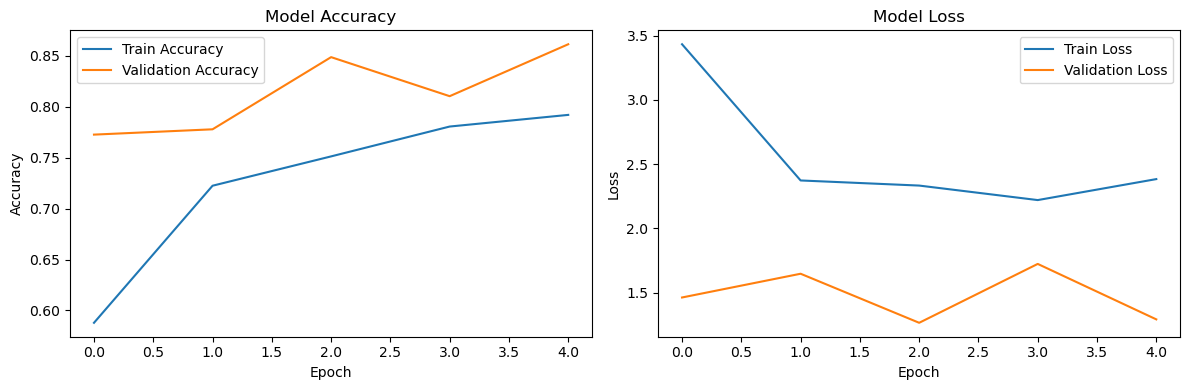

In [14]:
# Plot Accuracy
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


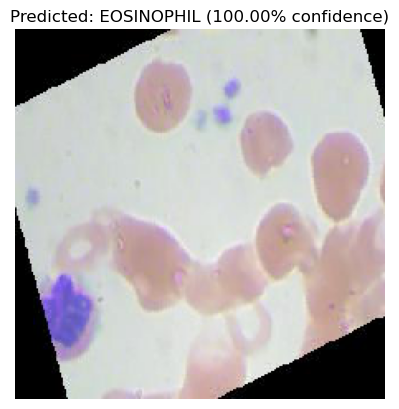

Prediction: EOSINOPHIL
Confidence: 100.00%


In [16]:
from tensorflow.keras.preprocessing import image

# Pick any blood cell image from your dataset to test
test_img_path = r"D:\HematoVision\archive\dataset2-master\dataset2-master\images\TEST\EOSINOPHIL\_0_187.jpeg"  # change filename as needed

# Load and prepare the image
img = image.load_img(test_img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
img_array = img_array / 255.0                   # Normalize

# Predict
prediction = model.predict(img_array)
class_names = list(train_data.class_indices.keys())
predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction) * 100

# Show result
plt.imshow(img)
plt.title(f"Predicted: {predicted_class} ({confidence:.2f}% confidence)")
plt.axis('off')
plt.show()

print(f"Prediction: {predicted_class}")
print(f"Confidence: {confidence:.2f}%")

In [18]:
if os.path.exists(r"D:\HematoVision\blood_cell.h5"):
    size = os.path.getsize(r"D:\HematoVision\blood_cell.h5") / (1024*1024)
    print(f"✅ Model saved successfully! Size: {size:.2f} MB")
else:
    print("❌ Model not found — re-run training cell")


✅ Model saved successfully! Size: 11.83 MB
